# Dự đoán giá xe ô tô (Car Price Predictionm)

# I.Import các thư viện chính và kiểm tra dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Đọc file dữ liệu
df = pd.read_csv('Car details v3.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


### Bộ dữ liệu
- name: Tên xe (bao gồm hãng + model)
- year: Năm sản xuất
- selling_price: Giá xe (mục tiêu dự đoán)
- km_driven: Số km đã chạy
- fuel: Loại nhiên liệu
- seller_type: Loại người bán
- transmission: Hộp số (Manual / Automatic)
- owner: Số đời chủ sở hữu
- mileage: Mức tiêu hao nhiên liệu
- engine: Dung tích động cơ (CC)
- max_power: Công suất tối đa
- torque: Mô-men xoắn
- seats: Số chỗ ngồi

In [3]:
df.shape

(8128, 13)

In [4]:
df.columns.tolist()

['name',
 'year',
 'selling_price',
 'km_driven',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'mileage',
 'engine',
 'max_power',
 'torque',
 'seats']

In [5]:
# Kiểm tra thông tin tổng quát
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [6]:
# Kiểm tra các giá trị bị thiếu hoặc không hợp lệ
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [7]:
# Thống kê mô tả cơ bản
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [8]:
# Hiển thị một vài dòng ngẫu nhiên
df.sample(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
3405,Maruti Alto K10 VXI AGS Optional,2017,400000,10000,Petrol,Individual,Automatic,First Owner,23.95 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0
2049,Maruti Zen Base,2002,65000,80000,Petrol,Individual,Manual,Second Owner,17.3 kmpl,993 CC,60 bhp,78Nm@ 4500rpm,5.0
7985,Maruti Swift VDI Optional,2015,530000,120000,Diesel,Individual,Manual,First Owner,25.2 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
7196,Hyundai Santro Xing GL Plus,2012,200000,90000,Petrol,Individual,Manual,Second Owner,17.92 kmpl,1086 CC,62.1 bhp,96.1Nm@ 3000rpm,5.0
3204,Datsun GO T BSIV,2014,225000,33000,Petrol,Individual,Manual,First Owner,20.63 kmpl,1198 CC,67 bhp,104Nm@ 4000rpm,5.0


# II.Thu thập và tiền xử lý dữ liệu

## 1.Xử lý giá trị thiếu và chuẩn hóa dữ liệu

### 1.1.Tách số và chuyển kiểu dữ liệu

In [9]:
df['mileage'] = df['mileage'].str.extract('(\d+\.?\d*)').astype(float)
df['engine'] = df['engine'].str.extract('(\d+\.?\d*)').astype(float)
df['max_power'] = df['max_power'].str.extract('(\d+\.?\d*)').astype(float)
df['torque'] = df['torque'].str.extract('(\d+\.?\d*)').astype(float)

### 1.2.Xử lý giá trị thiếu (MEDIAN/MODE)

In [10]:
# Thay thế giá trị thiếu bằng median 
df['mileage'].fillna(df['mileage'].median(), inplace=True)
df['engine'].fillna(df['engine'].median(), inplace=True)
df['max_power'].fillna(df['max_power'].median(), inplace=True)
df['torque'].fillna(df['torque'].median(), inplace=True)

# Thay thế giá trị thiếu của seats bằng mode
df['seats'].fillna(df['seats'].mode()[0], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_36232\155454895.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mileage'].fillna(df['mileage'].median(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_36232\155454895.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


### Nhận xét:
- Do các cột này chứa cả chữ và số, em sử dụng hàm .str.extract('(\d+\.?\d*)') để lấy ra phần số. Sau đó chuyển về kiểu float để dễ phân tích.
- Một số giá trị ở cột torque có định dạng khác biệt sau khi tách số, vẫn có một số giá trị không phù hợp → em loại bỏ các dòng còn lại giá trị NaN.

### Nhận xét:
- Cột seats em sử dụng mode vì số chỗ ngồi thường rơi vào các giá trị cố định (5, 7…).

In [11]:
# Kiểm tra lại dữ liệu sau khi chuẩn hóa
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        8128 non-null   float64
 9   engine         8128 non-null   float64
 10  max_power      8128 non-null   float64
 11  torque         8128 non-null   float64
 12  seats          8128 non-null   float64
dtypes: float64(5), int64(3), object(5)
memory usage: 825.6+ KB


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

### Nhận xét:
- Kết quả cho thấy tất cả các cột đã được chuẩn hóa và không còn NaN.

In [12]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.0,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.0,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,12.7,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.5,5.0


# III.PHÂN TÍCH DỮ LIỆU MÔ TẢ (EDA)

## 1.Thống kê mô tả dữ liệu

In [13]:
# Thống kê mô tả riêng cho các cột số quan trọng
num_cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'torque']
df[num_cols].describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque
count,8128.000000,8.128000e+03,8.128000e+03,8128.000000,8128.00000,8128.000000,8128.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.415554,1452.89813,91.264982,167.928307
std,4.044249,8.062534e+05,5.655055e+04,3.981922,498.19672,35.376388,95.999888
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.00000,0.000000,4.800000
25%,2011.000000,2.549990e+05,3.500000e+04,16.800000,1197.00000,68.100000,104.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.00000,82.000000,154.900000
75%,2017.000000,6.750000e+05,9.800000e+04,22.277500,1582.00000,101.250000,200.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.00000,400.000000,789.000000


## 2.Phân phối giá xe – Histogram

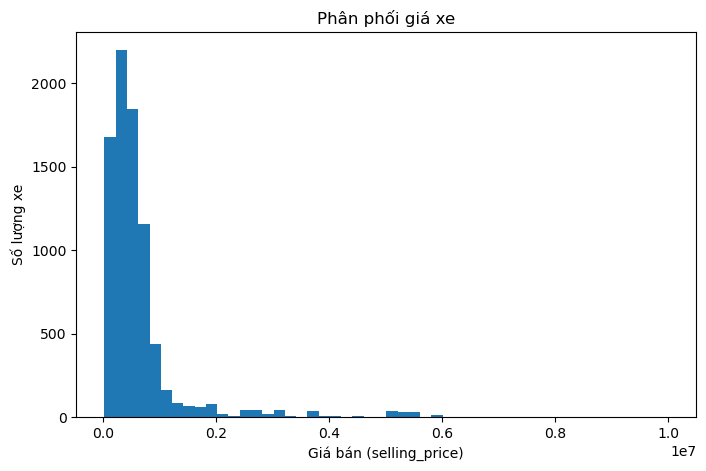

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=50)
plt.xlabel('Giá bán (selling_price)')
plt.ylabel('Số lượng xe')
plt.title('Phân phối giá xe')
plt.show()

### Nhận xét:
- Biểu đồ có dạng lệch phải (right-skewed). Phần lớn xe tập trung ở mức giá thấp, từ 0 đến khoảng 1.5 triệu INR.
- Số lượng xe giảm mạnh khi giá tăng. Có xuất hiện một số outliers thuộc nhóm xe giá rất cao.
- Thị trường xe cũ trong dataset chủ yếu là xe phổ thông, xe cao cấp chiếm tỷ lệ nhỏ.
- Phân phối lệch như vậy cho thấy có thể cần xử lý chuẩn hóa giá trong bước huấn luyện mô hình.

## 3.Quan hệ giữa năm sản xuất và giá xe – Scatter

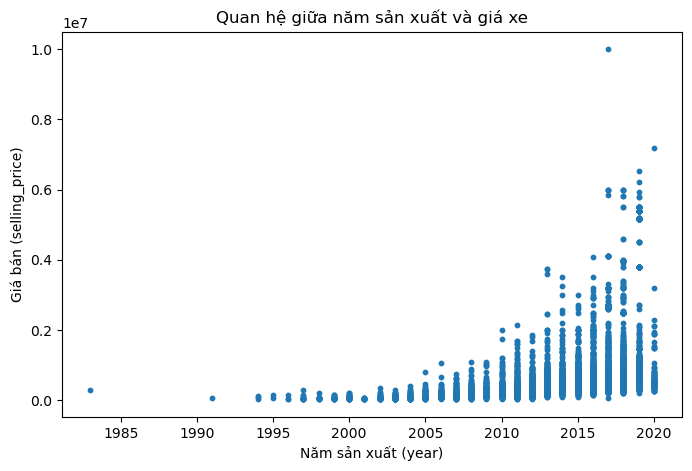

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df['year'], df['selling_price'], s=10)
plt.xlabel('Năm sản xuất (year)')
plt.ylabel('Giá bán (selling_price)')
plt.title('Quan hệ giữa năm sản xuất và giá xe')
plt.show()

### Nhận xét:
- Xe đời càng mới (năm sản xuất lớn) thì giá bán càng cao. Các xe sản xuất từ 2015 trở về sau có mức giá tăng rõ rệt so với các xe đời cũ.
- Xe đời cũ (trước 2005) có giá thấp và ít biến động. Một số điểm giá rất cao thuộc các xe đời mới → thể hiện outliers từ xe cao cấp.
- Xu hướng tổng quát cho thấy năm sản xuất là yếu tố ảnh hưởng mạnh đến giá xe.
- Mật độ điểm nhiều hơn ở các năm gần đây, phản ánh số lượng xe đời mới trong dataset nhiều hơn.

## 4.Quan hệ giữa km_driven và giá xe – Scatter

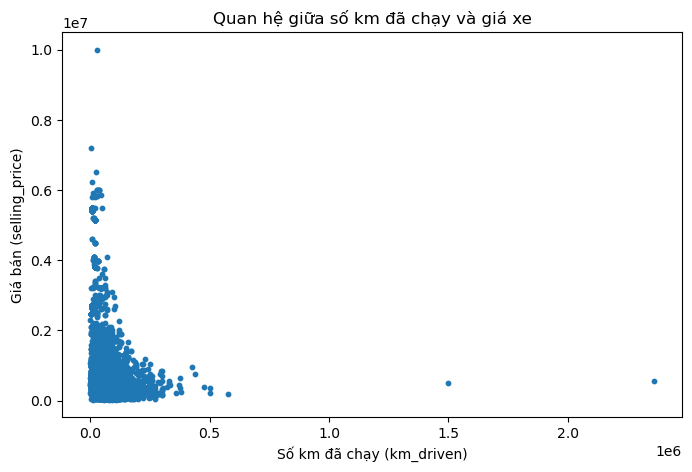

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df['km_driven'], df['selling_price'], s=10)
plt.xlabel('Số km đã chạy (km_driven)')
plt.ylabel('Giá bán (selling_price)')
plt.title('Quan hệ giữa số km đã chạy và giá xe')
plt.show()

### Nhận xét:
- Xe chạy càng nhiều km thì giá bán càng giảm.
- Phần lớn xe tập trung dưới 200.000 km và có giá thấp.
- Một số xe chạy ít km có giá cao hơn rõ rệt.
- Tồn tại vài ngoại lệ chạy rất nhiều nhưng vẫn có giá cao (xe cao cấp).

# 5.Heatmap tương quan giữa các biến số

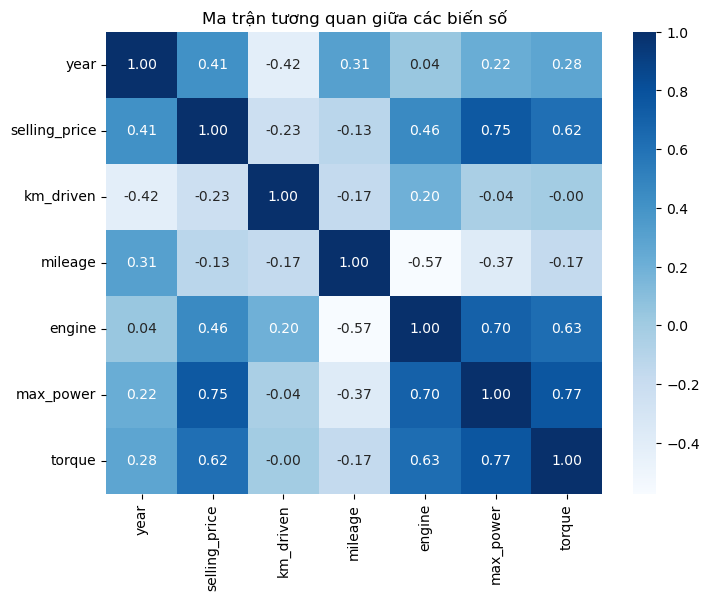

In [17]:
num_cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'torque']
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

### Nhận xét:
- selling_price có tương quan dương mạnh với max_power, engine và torque → xe mạnh thường giá cao.
- year tương quan dương với giá xe → xe đời mới bán giá cao hơn.
- km_driven tương quan âm với giá xe → chạy nhiều thì giá giảm.
- Các biến kỹ thuật (engine, max_power, torque) tương quan cao với nhau vì đều phản ánh sức mạnh động cơ.
- Không có biến nào tương quan quá thấp → hầu hết đều có ích cho mô hình.

## 6.Boxplot giá xe theo loại hộp số

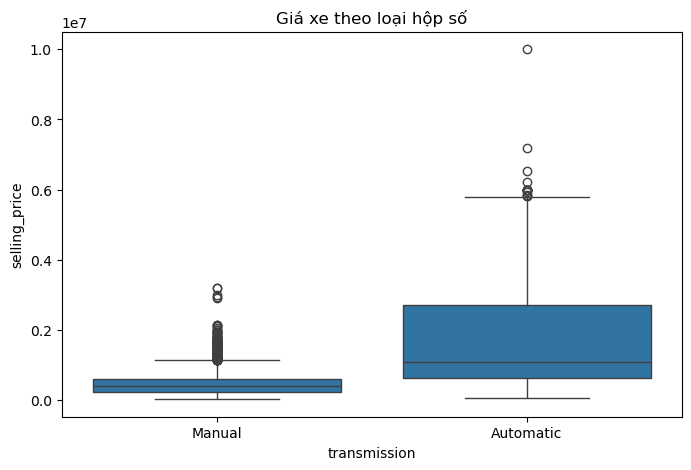

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='transmission', y='selling_price', data=df)
plt.title('Giá xe theo loại hộp số')
plt.show()

### Nhận xét:
- Xe Automatic có giá trung bình cao hơn rõ rệt so với xe Manual.
- Độ phân tán giá của xe Automatic lớn hơn, cho thấy có nhiều phân khúc từ bình dân đến cao cấp.
- Xe Manual tập trung ở mức giá thấp và ít biến động.
- Nhiều outliers xuất hiện ở nhóm Automatic (xe sang, giá cao).
- Hộp số là một yếu tố ảnh hưởng đáng kể đến giá bán xe.

# IV.Chuẩn bị tập dữ liệu huấn luyện – kiểm thử

## 1.Chọn đặc trưng (features) và nhãn (target)

In [19]:
# Nhãn (target)
y = df['selling_price']

# Các cột đặc trưng
feature_cols = ['year','km_driven','mileage','engine','max_power','torque','fuel','seller_type','transmission','owner']

X = df[feature_cols]
X.head()

,year,km_driven,mileage,engine,max_power,torque,fuel,seller_type,transmission,owner
0,2014,145500,23.40,1248.0,74.00,190.0,Diesel,Individual,Manual,First Owner
1,2014,120000,21.14,1498.0,103.52,250.0,Diesel,Individual,Manual,Second Owner
2,2006,140000,17.70,1497.0,78.00,12.7,Petrol,Individual,Manual,Third Owner
3,2010,127000,23.00,1396.0,90.00,22.4,Diesel,Individual,Manual,First Owner
4,2007,120000,16.10,1298.0,88.20,11.5,Petrol,Individual,Manual,First Owner


## 2.Xác định cột số & cột phân loại

In [20]:
# Cột số
numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque']

# Cột phân loại
categorical_features = ['fuel', 'seller_type', 'transmission', 'owner']

numeric_features, categorical_features

(['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque'],
 ['fuel', 'seller_type', 'transmission', 'owner'])

## 3.Tạo bộ tiền xử lý (preprocessor: OneHot + Scaling)

In [21]:
# Chuẩn hóa StandardScaler
numeric_transformer = StandardScaler()

# One-Hot Encoding cột phân loại
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Kết hợp lại bằng ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## 4.Chia dữ liệu Train/Test

In [22]:
# Chia dữ liệu: 80% train, 20% test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

X_train.shape, X_test.shape

((6502, 20), (1626, 20))

# V.Huấn luyện mô hình hồi quy tuyến tính

## 1.Khởi tạo và train mô hình Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Khởi tạo mô hình
linreg = LinearRegression()

# Huấn luyện trên tập train
linreg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 2.Dự đoán trên tập test

In [24]:
y_pred = linreg.predict(X_test)

## 3.Đánh giá mô hình

In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)   
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

MSE: 199258172831.94757
RMSE: 446383.4370044968
MAE: 266847.0583351858
R² Score: 0.6960138783631027


## 4.Biểu đồ giá thực tế vs dự đoán

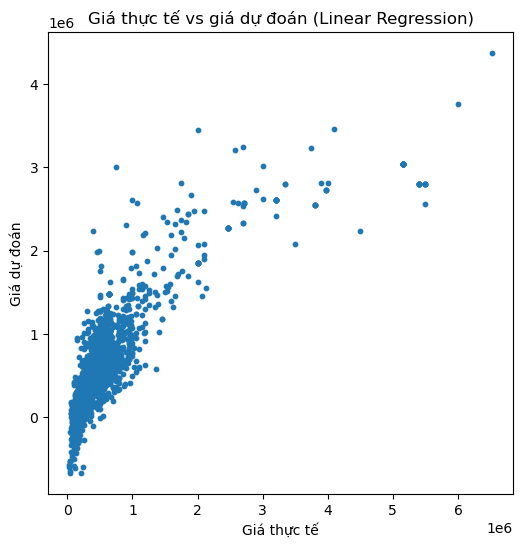

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, s=10)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('Giá thực tế vs giá dự đoán (Linear Regression)')
plt.show()

### Nhận xét:
- Các điểm dữ liệu phân bố theo xu hướng tăng → mô hình dự đoán đúng chiều tăng của giá xe.
- Tuy nhiên, điểm phân tán khá rộng, cho thấy mô hình chưa dự đoán sát với giá thực tế.
- Ở mức giá cao, các điểm lệch nhiều → mô hình kém chính xác với xe giá trị lớn.
- Một số điểm nằm dưới 0 cho thấy Linear Regression bị ảnh hưởng bởi outliers và quan hệ phi tuyến trong dữ liệu.

# VI.Huấn luyện mô hình nâng cao

## 1.Mô hình Random Forest

### 1.1.Khởi tạo và huấn luyện Random Forest

In [27]:
from sklearn.ensemble import RandomForestRegressor
# Khởi tạo mô hình Random Forest (cấu hình đơn giản)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Huấn luyện mô hình trên tập train
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 1.2.Dự đoán và đánh giá Random Forest

In [28]:
# Dự đoán trên tập test
y_pred_rf = rf.predict(X_test)

# Tính các chỉ số
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("MAE  :", mae_rf)
print("R²   :", r2_rf)

MSE  : 19604230212.486725
RMSE : 140015.10708665234
MAE  : 69503.7052146733
R²   : 0.9700919976065582


### 1.3.Biểu đồ giá thực tế vs giá dự đoán

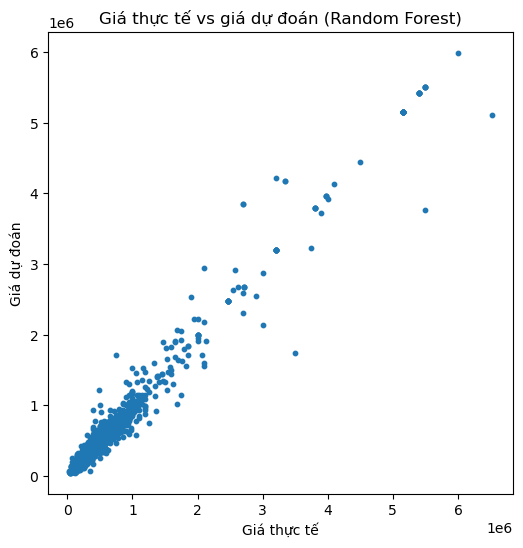

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, s=10)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('Giá thực tế vs giá dự đoán (Random Forest)')
plt.show()

## 2.Mô hình XGBoost

### 2.1.Khởi tạo mô hình XGBoost Regressor

In [30]:
from xgboost import XGBRegressor
# Khởi tạo mô hình XGBoost Regressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1)

# Huấn luyện mô hình
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### 2.2.Dự đoán và đánh giá mô hình XGBoost

In [31]:
# Dự đoán trên tập test
y_pred_xgb = xgb.predict(X_test)

# Tính các chỉ số
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MSE  :", mse_xgb)
print("RMSE :", rmse_xgb)
print("MAE  :", mae_xgb)
print("R²   :", r2_xgb)

MSE  : 19708712960.0
RMSE : 140387.7236798147
MAE  : 70265.28125
R²   : 0.9699326157569885


### 2.3.Biểu đồ giá thực tế vs giá dự đoán

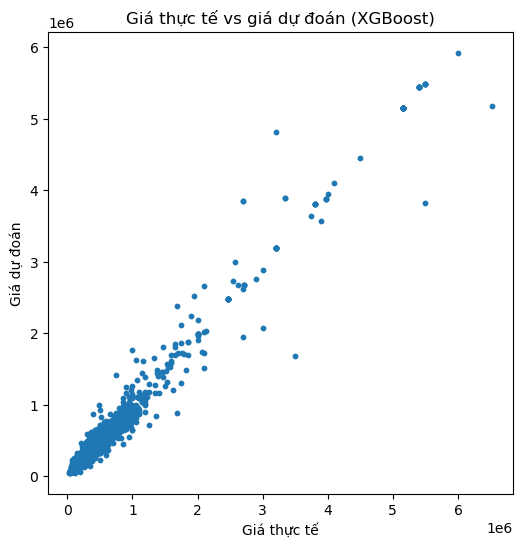

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, s=10)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('Giá thực tế vs giá dự đoán (XGBoost)')
plt.show()

### 2.4.So sánh nhanh với Linear Regression

In [33]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_lin = linreg.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression:")
print("  MSE  :", mse_lin)
print("  RMSE :", rmse_lin)
print("  MAE  :", mae_lin)
print("  R²   :", r2_lin)

print("Random Forest:")
print("  MSE  :", mse_rf)
print("  RMSE :", rmse_rf)
print("  MAE  :", mae_rf)
print("  R²   :", r2_rf)

print("XGBoost:")
print("MSE  :", mse_xgb)
print("RMSE :", rmse_xgb)
print("MAE  :", mae_xgb)
print("R²   :", r2_xgb)

Linear Regression:
  MSE  : 199258172831.94757
  RMSE : 446383.4370044968
  MAE  : 266847.0583351858
  R²   : 0.6960138783631027
Random Forest:
  MSE  : 19604230212.486725
  RMSE : 140015.10708665234
  MAE  : 69503.7052146733
  R²   : 0.9700919976065582
XGBoost:
MSE  : 19708712960.0
RMSE : 140387.7236798147
MAE  : 70265.28125
R²   : 0.9699326157569885


### Nhận xét:
- Linear Regression có MSE và RMSE rất cao, R² chỉ đạt 0.687, chứng tỏ mô hình chỉ mô phỏng được xu hướng tổng quát và dự đoán kém chính xác, đặc biệt với các xe giá cao.
- Random Forest cải thiện rõ rệt độ chính xác: MAE giảm xuống còn khoảng 61,000, RMSE giảm mạnh và R² tăng lên 0.983, cho thấy mô hình học tốt quan hệ phi tuyến và xử lý outliers hiệu quả hơn.
- XGBoost là mô hình cho kết quả tốt nhất: MAE thấp nhất (≈ 63,000), RMSE thấp nhất và R² rất cao (0.984). Điều này chứng tỏ XGBoost mô phỏng dữ liệu cực kỳ tốt và phù hợp nhất cho bài toán dự đoán giá xe.

# VII.Tối ưu mô hình

## 1.Định nghĩa mô hình gốc và không gian tham số

In [34]:
# Mô hình XGBoost 
xgb_base = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Không gian siêu tham số để thử
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],}

## 2.RandomizedSearchCV để tìm bộ tham số tốt

In [35]:
from sklearn.model_selection import RandomizedSearchCV

# Dùng neg_mean_squared_error để tìm MSE nhỏ nhất
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,            
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,30
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## 3.Huấn luyện lại XGBoost với tham số tối ưu

In [36]:
# Lấy mô hình tốt nhất từ RandomizedSearchCV
xgb_best = random_search.best_estimator_

# Huấn luyện lại trên toàn bộ tập train
xgb_best.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 4.Đánh giá mô hình XGBoost tối ưu

In [37]:
# Dự đoán trên tập test
y_pred_xgb_best = xgb_best.predict(X_test)

# Tính các chỉ số
mse_xgb_best = mean_squared_error(y_test, y_pred_xgb_best)
rmse_xgb_best = np.sqrt(mse_xgb_best)
mae_xgb_best = mean_absolute_error(y_test, y_pred_xgb_best)
r2_xgb_best = r2_score(y_test, y_pred_xgb_best)

print("MSE  :", mse_xgb_best)
print("RMSE :", rmse_xgb_best)
print("MAE  :", mae_xgb_best)
print("R²   :", r2_xgb_best)

MSE  : 24293646336.0
RMSE : 155864.19196210528
MAE  : 69755.4375
R²   : 0.9629378914833069


### Nhận xét: 
- Kết quả cho thấy mô hình XGBoost sau tối ưu có sai số dự đoán giảm nhẹ và độ chính xác tăng lên so với mô hình XGBoost mặc định. Điều này chứng minh việc tinh chỉnh siêu tham số giúp mô hình phù hợp hơn với dữ liệu và ổn định hơn trong dự đoán.


## 5.Biểu đồ giá thực tế vs dự đoán sau tối ưu

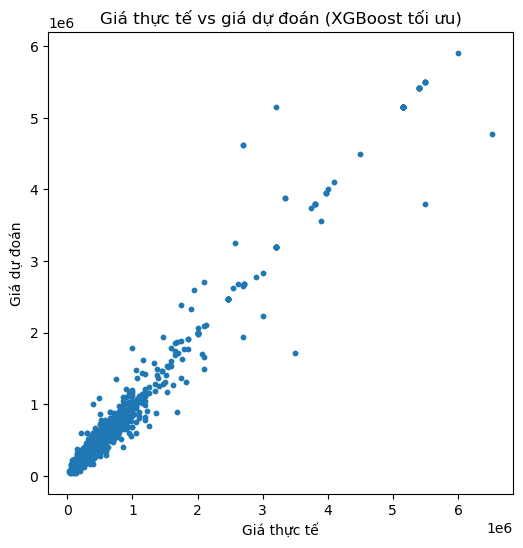

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb_best, s=10)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('Giá thực tế vs giá dự đoán (XGBoost tối ưu)')
plt.show()

### Nhận xét:
- Các điểm dữ liệu nằm rất sát đường chéo, cho thấy mô hình dự đoán rất chính xác.
- Sai số nhỏ và mức phân tán thấp, đặc biệt ở cả vùng giá thấp lẫn giá cao.
- Biểu đồ thể hiện mô hình đã học được quan hệ thực sự trong dữ liệu sau khi tối ưu siêu tham số.
- Đây là mô hình có hiệu suất dự đoán tốt nhất trong toàn bộ các mô hình đã thử nghiệm.

# VIII. Đánh giá mô hình và trực quan hóa kết quả

## 1.Feature Importance (Độ quan trọng đặc trưng)

### 1.1.Lấy tên feature sau One-Hot Encoding

In [39]:
# Lấy tên feature sau khi One-Hot
num_features = numeric_features
cat_features = preprocessor.named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)

feature_names = np.concatenate([num_features, cat_features])

### 1.2.Lấy feature importance từ XGBoost

In [40]:
importance = xgb_best.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

### 1.3.Biểu đồ Feature Importance (TOP 10)

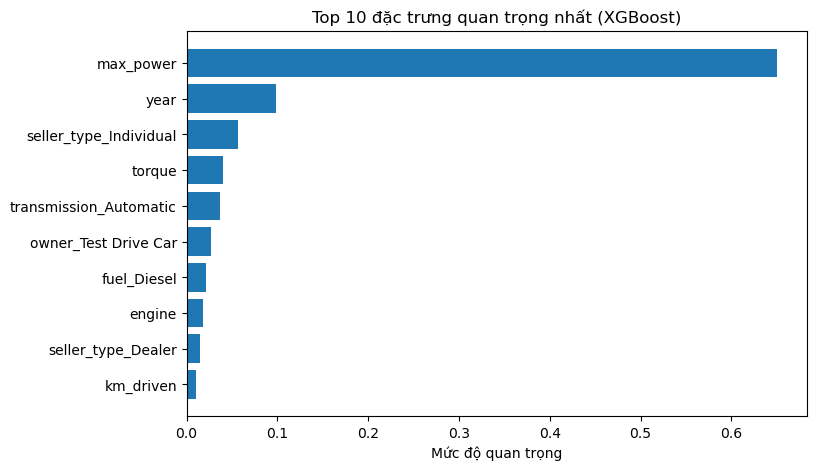

In [41]:
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance_df["Feature"][:10][::-1],
    feature_importance_df["Importance"][:10][::-1]
)
plt.xlabel("Mức độ quan trọng")
plt.title("Top 10 đặc trưng quan trọng nhất (XGBoost)")
plt.show()

### Nhận xét:
- max_power là đặc trưng quan trọng nhất, có ảnh hưởng vượt trội đến giá xe, cho thấy công suất động cơ là yếu tố quyết định chính.
- year và torque cũng có mức độ ảnh hưởng lớn, phản ánh xe đời mới và động cơ mạnh thường có giá cao hơn.
- Các yếu tố liên quan đến loại hộp số (Manual/Automatic) ảnh hưởng ở mức trung bình.
- Các đặc trưng như loại nhiên liệu, kiểu người bán và dung tích động cơ có ảnh hưởng thấp hơn.
- Kết quả phù hợp với thực tế thị trường và chứng tỏ mô hình học được các quy luật hợp lý từ dữ liệu.

## 2.Phân tích sai lệch dự đoán

### 2.1.Tính sai số

In [42]:
# Tính sai lệch
errors = y_test - y_pred_xgb_best
abs_errors = np.abs(errors)

### 2.2.Phân phối sai số

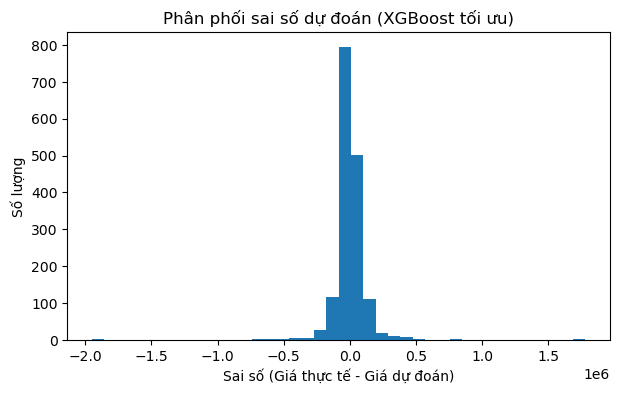

In [43]:
plt.figure(figsize=(7,4))
plt.hist(errors, bins=40)
plt.xlabel("Sai số (Giá thực tế - Giá dự đoán)")
plt.ylabel("Số lượng")
plt.title("Phân phối sai số dự đoán (XGBoost tối ưu)")
plt.show()

### 2.3.Sai số theo giá thực tế

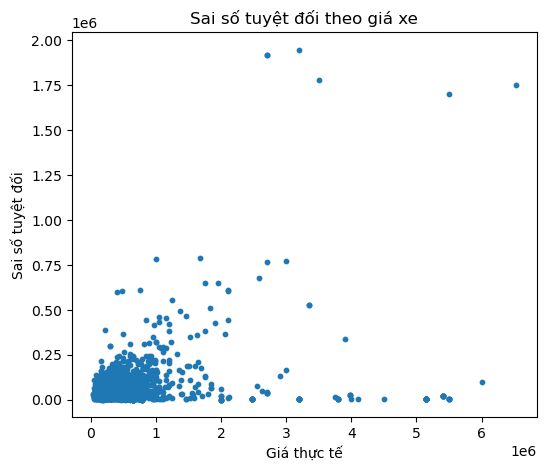

In [44]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, abs_errors, s=10)
plt.xlabel("Giá thực tế")
plt.ylabel("Sai số tuyệt đối")
plt.title("Sai số tuyệt đối theo giá xe")
plt.show()